In [15]:
# %%codecell
%pip install opencv-python scikit-image tensorflow numpy matplotlib --quiet
print("Dependencies installed successfully!")


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Dependencies installed successfully!


In [16]:
# %%codecell
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from skimage import morphology
from scipy.ndimage import gaussian_filter, map_coordinates
import os
from IPython.display import display, HTML, clear_output
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("All libraries imported successfully!")

All libraries imported successfully!


In [17]:
# %%codecell
def create_cnn_model():
    """Create enhanced CNN model with dropout and batch normalization"""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    
    model.summary()
    return model

Loaded pre-trained model


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,370 (1.26 MB)

...

 Non-trainable params: 704 (2.75 KB)

Epoch 1/20


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.7254 - loss: 0.9238 - val_accuracy: 0.5295 - val_loss: 1.3491
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9517 - loss: 0.1538 - val_accuracy: 0.9891 - val_loss: 0.0340
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9692 - loss: 0.1019 - val_accuracy: 0.9918 - val_loss: 0.0243
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9743 - loss: 0.0834 - val_accuracy: 0.9934 - val_loss: 0.0199
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.9757 - loss: 0.0756 - val_accuracy: 0.9911 - val_loss: 0.0251
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9787 - loss: 0.0707 - val_accuracy: 0.9913 - val_loss: 0.0255
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9809 - loss: 0.0627 - val_accuracy: 0.9933 - val_loss: 0.0199
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9816 - loss: 0.0572 - val_accurac

Model saved to digit_cnn_enhanced.h5


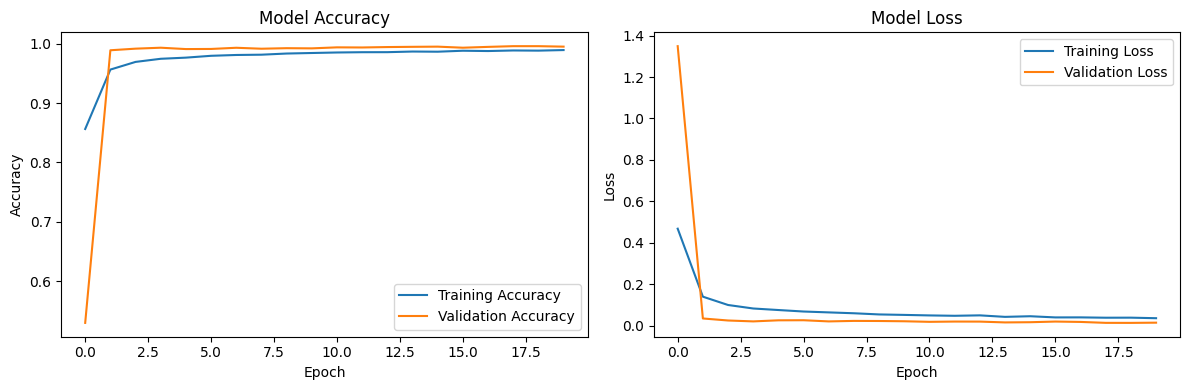

Macro-averaged F1 Score on Test Set: 0.9952


In [ ]:
# %%codecell
MODEL_PATH = 'digit_cnn_enhanced.h5'

if os.path.exists(MODEL_PATH):
    model = load_model(MODEL_PATH)
    print("Loaded pre-trained model")
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    y_train = to_categorical(y_train, 10)
    y_test = to_categorical(y_test, 10)
    
    # Data augmentation
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        shear_range=0.1,
        fill_mode='constant',
        cval=0
    )
    
    model = create_cnn_model()
    
    history = model.fit(
        datagen.flow(x_train, y_train, batch_size=128),
        epochs=20,
        validation_data=(x_test, y_test),
        verbose=1
    )
    
    model.save(MODEL_PATH)
    print(f"Model saved to {MODEL_PATH}")
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Training new model...")
    
    # Load and prepare MNIST data
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    y_train = to_categorical(y_train, 10)
    y_test = to_categorical(y_test, 10)
    
    # Data augmentation
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        shear_range=0.1,
        fill_mode='constant',
        cval=0
    )
    
    model = create_cnn_model()
    
    history = model.fit(
        datagen.flow(x_train, y_train, batch_size=128),
        epochs=20,
        validation_data=(x_test, y_test),
        verbose=1
    )
    
    model.save(MODEL_PATH)
    print(f"Model saved to {MODEL_PATH}")
    
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    # Now compute F1 Score


y_pred = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

f1 = f1_score(y_true, y_pred_classes, average='macro')
print(f"Macro-averaged F1 Score on Test Set: {f1:.4f}")

In [19]:
def robust_digit_preprocessor(image_path, verbose=False):
    """Enhanced preprocessing that handles various digit image cases"""
    try:
        # 1. Load image with multiple fallbacks
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError("Image not found or couldn't be loaded")
        
        if verbose:
            plt.figure(figsize=(6, 3))
            plt.subplot(1, 2, 1)
            plt.imshow(img, cmap='gray')
            plt.title("Original Image")
        
        # 2. Dynamic thresholding
        if np.mean(img) > 127:  # Light background
            thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
        else:  # Dark background
            thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
        
        # 3. Morphological operations to clean up
        kernel = np.ones((2, 2), np.uint8)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        
        # 4. Find contours with relaxed parameters
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            if verbose:
                plt.subplot(1, 2, 2)
                plt.imshow(thresh, cmap='gray')
                plt.title("No contours found")
                plt.show()
            return None
        
        # 5. Get largest reasonable contour
        contours = sorted(contours, key=cv2.contourArea, reverse=True)[:1]  # Take only the largest
        x, y, w, h = cv2.boundingRect(contours[0])
        
        # 6. Extract ROI with dynamic padding
        padding = max(5, int(min(w, h) * 0.2))  # Padding proportional to digit size
        roi = thresh[max(0, y-padding):min(img.shape[0], y+h+padding),
                    max(0, x-padding):min(img.shape[1], x+w+padding)]
        
        # 7. Resize with aspect ratio preservation
        target_height = 20
        aspect_ratio = roi.shape[1] / roi.shape[0]
        if aspect_ratio > 1.5:  # Very wide (like '1')
            resized_w = target_height
            resized_h = max(8, int(target_height / aspect_ratio))
        else:
            resized_h = target_height
            resized_w = int(target_height * aspect_ratio)
            
        resized = cv2.resize(roi, (resized_w, resized_h), interpolation=cv2.INTER_AREA)
        
        # 8. Center in 28x28 canvas
        canvas = np.zeros((28, 28), dtype=np.uint8)
        start_y = (28 - resized_h) // 2
        start_x = (28 - resized_w) // 2
        canvas[start_y:start_y+resized_h, start_x:start_x+resized_w] = resized
        
        # 9. Final processing
        processed = canvas.astype('float32') / 255.0
        processed = np.expand_dims(processed, axis=(0, -1))  # Add batch and channel dimensions
        
        if verbose:
            plt.subplot(1, 2, 2)
            plt.imshow(processed.squeeze(), cmap='gray')
            plt.title("Processed Digit")
            plt.show()
            
        return processed
        
    except Exception as e:
        if verbose:
            print(f"Preprocessing error: {str(e)}")
        return None

def predict_digit_robust(image_path, verbose=True):
    """Robust prediction function with detailed error handling"""
    try:
        processed = robust_digit_preprocessor(image_path, verbose)
        if processed is None:
            print("Could not process image. Common reasons:")
            print("- No clear digit found")
            print("- Low contrast between digit and background")
            print("- Digit too small or too large")
            print("- Multiple digits detected (system expects single digit)")
            return None, 0.0
        
        pred = model.predict(processed, verbose=0)
        digit = np.argmax(pred)
        confidence = np.max(pred)
        
        if verbose:
            plt.figure(figsize=(8, 4))
            plt.subplot(1, 2, 1)
            original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            plt.imshow(original, cmap='gray')
            plt.title("Original Image")
            plt.axis('off')
            
            plt.subplot(1, 2, 2)
            plt.imshow(processed.squeeze(), cmap='gray')
            plt.title(f"Predicted: {digit}\nConfidence: {confidence:.1%}")
            plt.axis('off')
            plt.show()
        
        return digit, confidence
        
    except Exception as e:
        print(f"Prediction error: {str(e)}")
        return None, 0.0

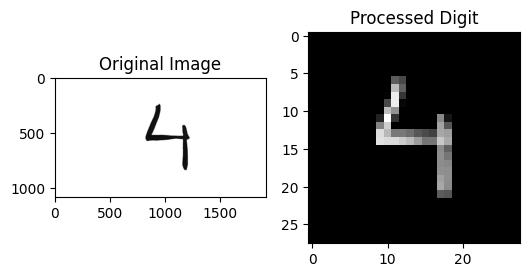

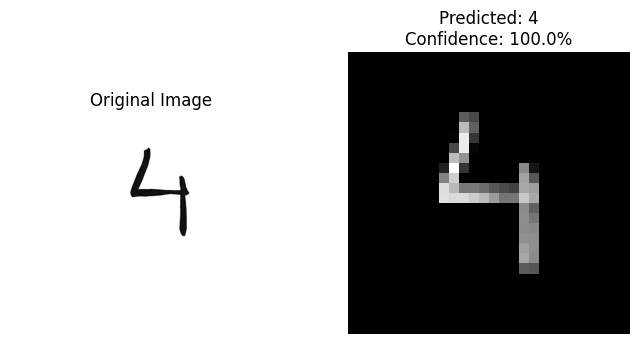


Final Prediction: Digit 4 with 100.0% confidence


In [20]:
TEST_IMAGE = "/Users/divyadilawrii_/Downloads/1.png"
if os.path.exists(TEST_IMAGE):
    digit, confidence = predict_digit_robust(TEST_IMAGE)
    if digit is not None:
        print(f"\nFinal Prediction: Digit {digit} with {confidence:.1%} confidence")
else:
    print(f"Image not found at: {TEST_IMAGE}")

In [21]:


# Predict on the test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculate F1 score (macro averages across digits)
f1 = f1_score(y_true, y_pred_classes, average='macro')
print(f"Macro-averaged F1 Score: {f1:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Macro-averaged F1 Score: 0.9952


<Figure size 1000x800 with 0 Axes>

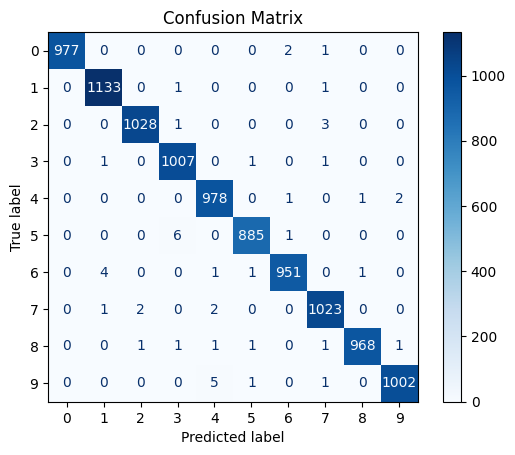

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Ensure predictions
y_pred = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Create and plot confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
